# Stock Forecast Testing — 20 Suku Cadang Honda AHASS

Test berbagai model regresi pada data 1 tahun (365 hari) suku cadang Honda.

**Models tested:**
1. Simple Linear Regression (slope * day)
2. Multi Linear Regression OLS (lag features + dow)
3. Average daily consumption (baseline)
4. Day-of-week pattern (current production model)

**Dataset:** `honda-dummy.json` — 20 sparepart, 6736 transaksi

## 1. Setup & Load Data

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette('husl')

MS_PER_DAY = 86400000

# Load dummy data
with open('../honda-dummy.json', 'r') as f:
    data = json.load(f)

inventory = data['inventory']
transactions = data['transactions']

print(f'Inventory: {len(inventory)} items')
print(f'Transactions: {len(transactions)} records')

Inventory: 20 items
Transactions: 6736 records


## 2. Build Daily Stock Series

Rekonstruksi level stok per hari per item dari transaksi.

In [2]:
def build_daily_series(transactions, current_quantity):
    """Rebuild daily stock level from transaction history."""
    daily_delta = {}
    for tx in transactions:
        ts = int(tx['timestamp'])
        qty = int(tx['quantity'])
        tx_type = tx.get('type', 'out')
        day_key = (ts // MS_PER_DAY) * MS_PER_DAY
        signed_qty = -abs(qty) if tx_type == 'out' else abs(qty)
        daily_delta[day_key] = daily_delta.get(day_key, 0) + signed_qty

    days = sorted(daily_delta.keys())
    if not days:
        return pd.DataFrame()

    total_delta = sum(daily_delta.values())
    level = current_quantity - total_delta

    rows = []
    for day in days:
        level += daily_delta[day]
        rows.append({'date': pd.to_datetime(day, unit='ms'), 'quantity': max(0, level), 'delta': daily_delta[day]})
    return pd.DataFrame(rows)

# Group transactions per item
tx_per_item = {}
for tx_id, tx in transactions.items():
    item_id = tx['itemId']
    tx_per_item.setdefault(item_id, []).append(tx)

# Build series per item
series_per_item = {}
for item_id, item in inventory.items():
    tx_list = tx_per_item.get(item_id, [])
    df = build_daily_series(tx_list, item['quantity'])
    if len(df) >= 30:
        series_per_item[item_id] = df

print(f'Items dengan ≥30 hari data: {len(series_per_item)}')

# Pilih 1 item untuk eksplorasi detail
sample_id = 'ahm-oil-spx2-08231-m99-k2lat'
sample_name = inventory[sample_id]['name']
df_sample = series_per_item[sample_id]
print(f'\nSample item: {sample_name}')
print(f'Days: {len(df_sample)} | Min stok: {df_sample.quantity.min()} | Max: {df_sample.quantity.max()}')

Items dengan ≥30 hari data: 20

Sample item: Oli AHM SPX2 SAE 10W-30 0.8L
Days: 336 | Min stok: 21 | Max: 120


## 3. Visualisasi Stok 1 Tahun

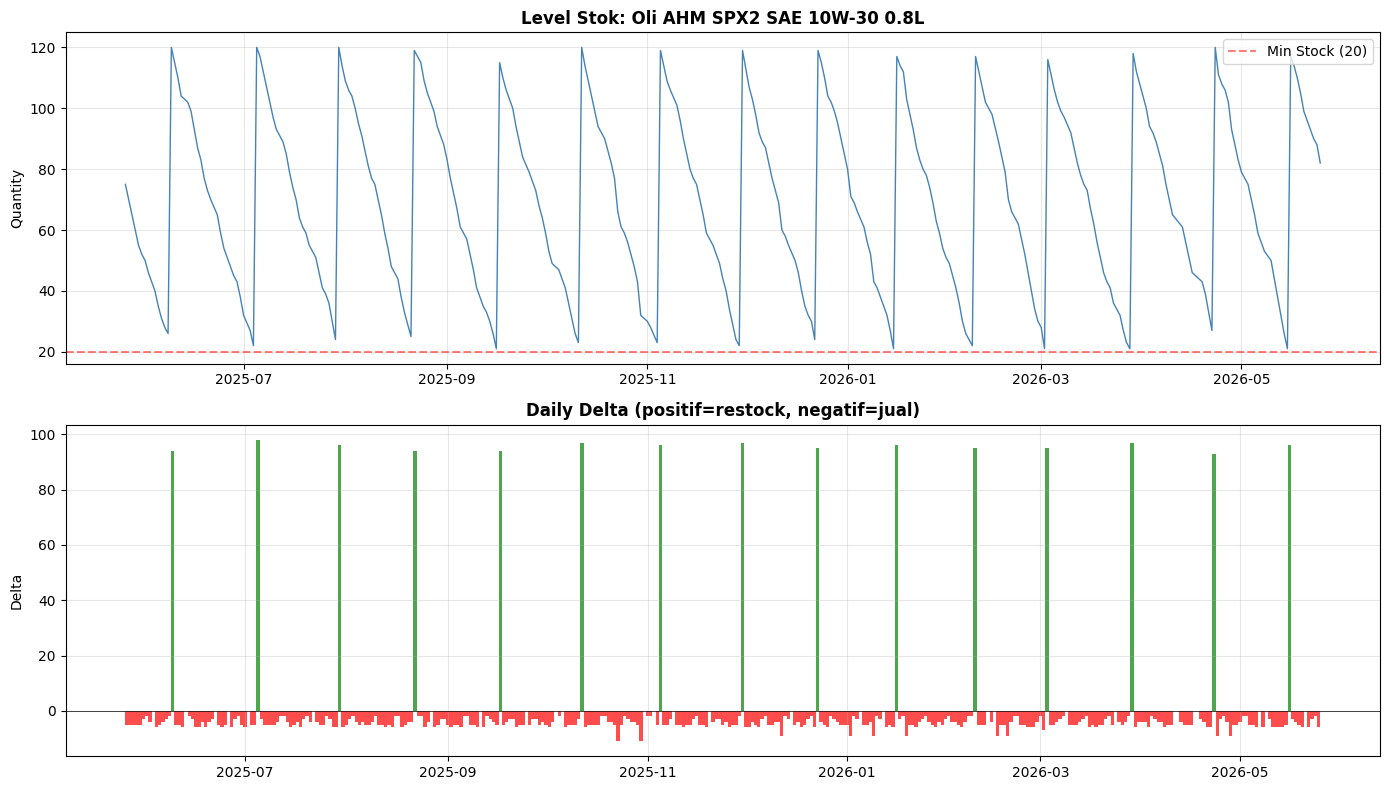

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_sample['date'], df_sample['quantity'], linewidth=1, color='steelblue')
axes[0].set_title(f'Level Stok: {sample_name}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Quantity')
axes[0].grid(alpha=0.3)
axes[0].axhline(inventory[sample_id]['minStock'], color='red', linestyle='--', alpha=0.5, label=f"Min Stock ({inventory[sample_id]['minStock']})")
axes[0].legend()

axes[1].bar(df_sample['date'], df_sample['delta'], color=['green' if d > 0 else 'red' for d in df_sample['delta']], alpha=0.7, width=1)
axes[1].set_title('Daily Delta (positif=restock, negatif=jual)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Delta')
axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## 4. Feature Engineering

Build features untuk Multi Linear Regression.

In [4]:
def build_features(df):
    """Build features for prediction."""
    df = df.copy().reset_index(drop=True)
    df['day_of_week'] = df['date'].dt.dayofweek  # 0=Mon..6=Sun
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['day_number'] = range(len(df))

    # Lag features
    df['lag1'] = df['quantity'].shift(1)
    df['lag3'] = df['quantity'].shift(3)
    df['lag7'] = df['quantity'].shift(7)

    # Rolling stats (7 hari)
    df['rolling_mean_7'] = df['quantity'].shift(1).rolling(7).mean()
    df['rolling_std_7'] = df['quantity'].shift(1).rolling(7).std()

    # Daily change
    df['daily_change'] = df['quantity'].diff()

    return df.dropna().reset_index(drop=True)

df_feat = build_features(df_sample)
print(f'Shape: {df_feat.shape}')
df_feat.head()

Shape: (329, 12)


,date,quantity,delta,day_of_week,is_weekend,day_number,lag1,lag3,lag7,rolling_mean_7,rolling_std_7,daily_change
0,2025-06-02,46,-4,0,0,7,50.0,55.0,75.0,61.000000,9.416298,-4.0
1,2025-06-04,40,-6,2,0,8,46.0,52.0,70.0,56.857143,8.571825,-6.0
2,2025-06-05,35,-5,3,0,9,40.0,50.0,65.0,52.571429,8.403514,-5.0
3,2025-06-06,31,-4,4,0,10,35.0,46.0,60.0,48.285714,8.654754,-4.0
4,2025-06-07,28,-3,5,1,11,31.0,40.0,55.0,44.142857,9.044862,-3.0


## 5. Korelasi Variabel

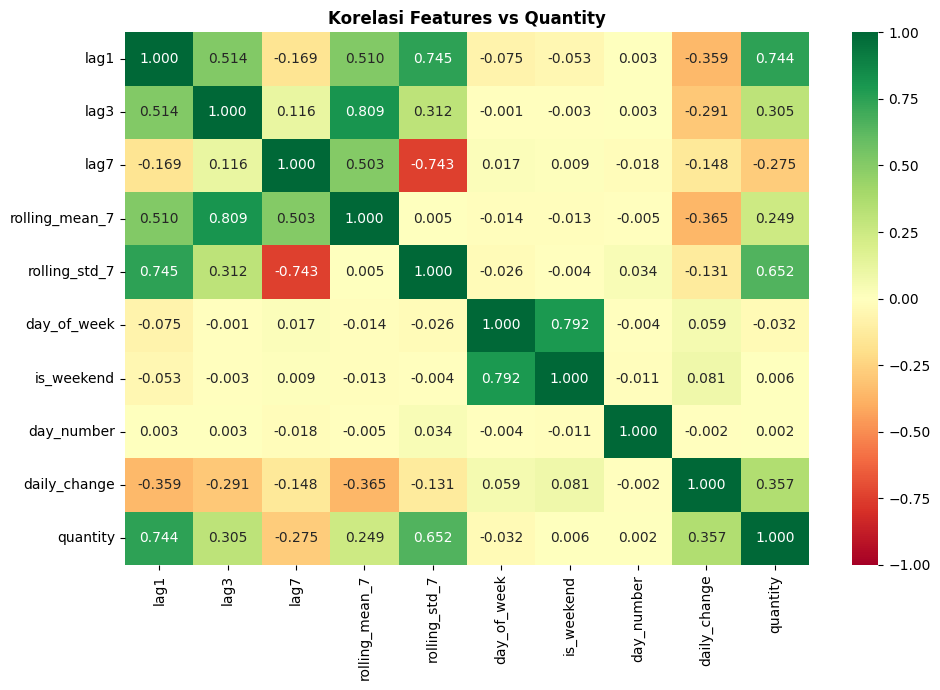


Korelasi terhadap quantity (sorted):
lag1              0.743634
rolling_std_7     0.652168
daily_change      0.357399
lag3              0.305220
rolling_mean_7    0.248654
is_weekend        0.005594
day_number        0.001744
day_of_week      -0.032476
lag7             -0.275338
Name: quantity, dtype: float64


In [5]:
feat_cols = ['lag1', 'lag3', 'lag7', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'is_weekend', 'day_number', 'daily_change']
target_col = 'quantity'

corr = df_feat[feat_cols + [target_col]].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0, vmin=-1, vmax=1)
plt.title('Korelasi Features vs Quantity', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKorelasi terhadap quantity (sorted):')
print(corr[target_col].drop(target_col).sort_values(ascending=False))

## 6. Train/Test Split + 4 Model Comparison

In [6]:
# Untuk forecasting realistis, target = quantity besok (shift -1)
df_feat['target'] = df_feat['quantity'].shift(-1)
df_feat = df_feat.dropna().reset_index(drop=True)

split_idx = int(len(df_feat) * 0.8)
train = df_feat.iloc[:split_idx]
test = df_feat.iloc[split_idx:]

print(f'Train: {len(train)} | Test: {len(test)}')

# Model 1: Simple Linear (day_number → quantity)
X1_train = train[['day_number']].values
y_train = train['target'].values
X1_test = test[['day_number']].values
y_test = test['target'].values

m1 = LinearRegression().fit(X1_train, y_train)
y_pred_m1 = m1.predict(X1_test)

# Model 2: Multi Linear (semua features) — non-scaled
X2_train = train[feat_cols].values
X2_test = test[feat_cols].values
m2 = LinearRegression().fit(X2_train, y_train)
y_pred_m2 = m2.predict(X2_test)

# Model 3: Multi Linear + StandardScaler
scaler = StandardScaler()
X3_train = scaler.fit_transform(X2_train)
X3_test = scaler.transform(X2_test)
m3 = LinearRegression().fit(X3_train, y_train)
y_pred_m3 = m3.predict(X3_test)

# Model 4: Statsmodels OLS (dengan p-value)
X4_train = sm.add_constant(X3_train)
X4_test = sm.add_constant(X3_test)
m4 = sm.OLS(y_train, X4_train).fit()
y_pred_m4 = m4.predict(X4_test)

def report(name, y_true, y_pred):
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²': r2_score(y_true, y_pred),
    }

results = pd.DataFrame([
    report('Simple Linear (day)', y_test, y_pred_m1),
    report('Multi Linear (raw)', y_test, y_pred_m2),
    report('Multi Linear (scaled)', y_test, y_pred_m3),
    report('Statsmodels OLS', y_test, y_pred_m4),
])
results

Train: 262 | Test: 66


,Model,MAE,RMSE,R²
0,Simple Linear (day),24.793695,28.688471,-0.005271
1,Multi Linear (raw),9.965012,18.806781,0.567986
2,Multi Linear (scaled),9.965012,18.806781,0.567986
3,Statsmodels OLS,9.965012,18.806781,0.567986


## 7. Visualisasi Prediksi Test Set

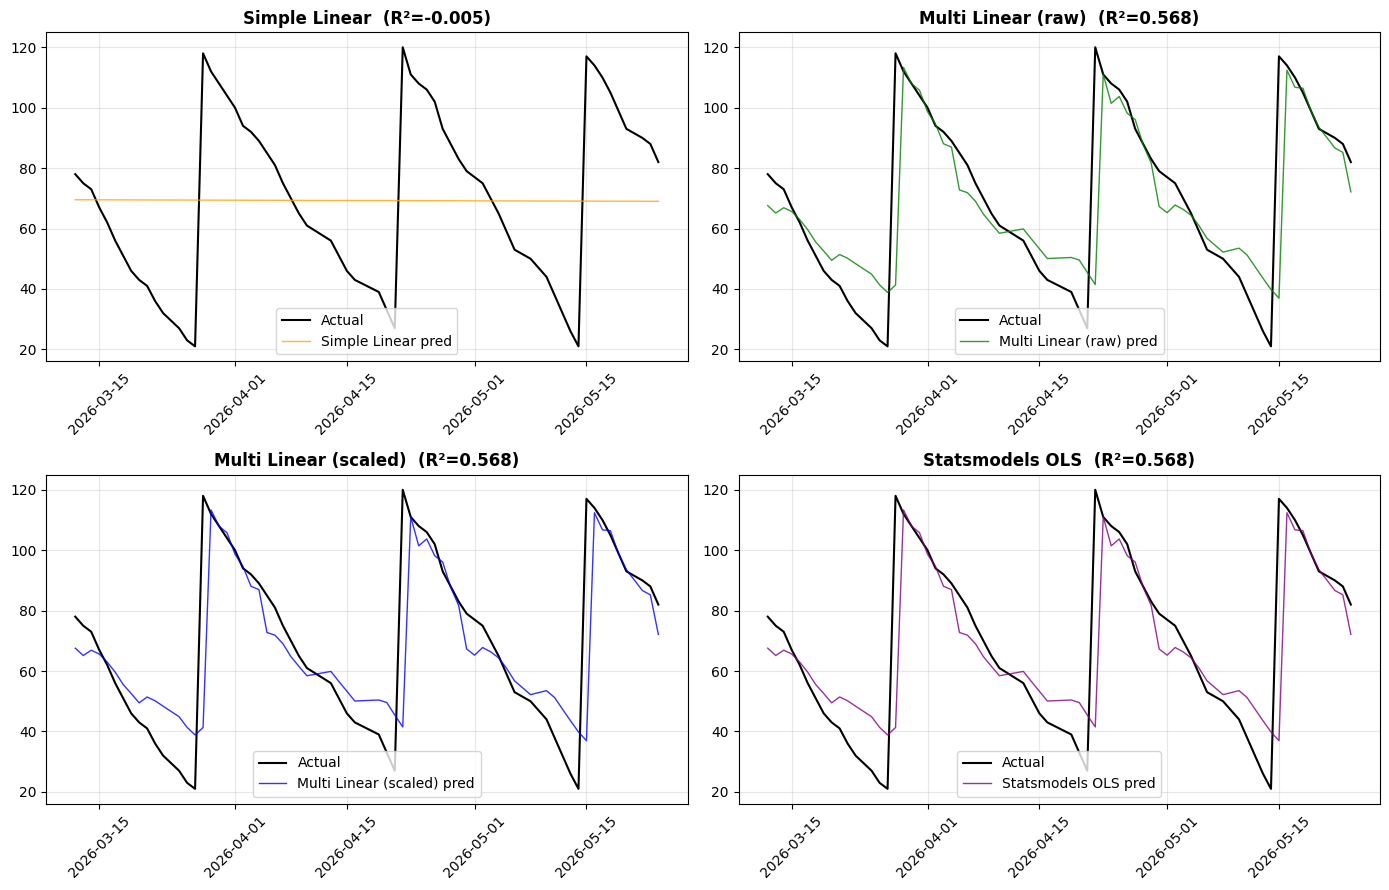

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (name, y_pred, color) in zip(axes.flat, [
    ('Simple Linear', y_pred_m1, 'orange'),
    ('Multi Linear (raw)', y_pred_m2, 'green'),
    ('Multi Linear (scaled)', y_pred_m3, 'blue'),
    ('Statsmodels OLS', y_pred_m4, 'purple'),
]):
    ax.plot(test['date'].values, y_test, label='Actual', color='black', linewidth=1.5)
    ax.plot(test['date'].values, y_pred, label=f'{name} pred', color=color, linewidth=1, alpha=0.8)
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{name}  (R²={r2:.3f})', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Statsmodels OLS Summary (lengkap)

In [8]:
print(m4.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     40.55
Date:                Tue, 26 May 2026   Prob (F-statistic):           3.40e-44
Time:                        07:03:21   Log-Likelihood:                -1140.0
No. Observations:                 262   AIC:                             2300.
Df Residuals:                     252   BIC:                             2336.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         70.5878      1.183     59.692      0.0

## 9. Iterative Forecast 14 Hari Ke Depan

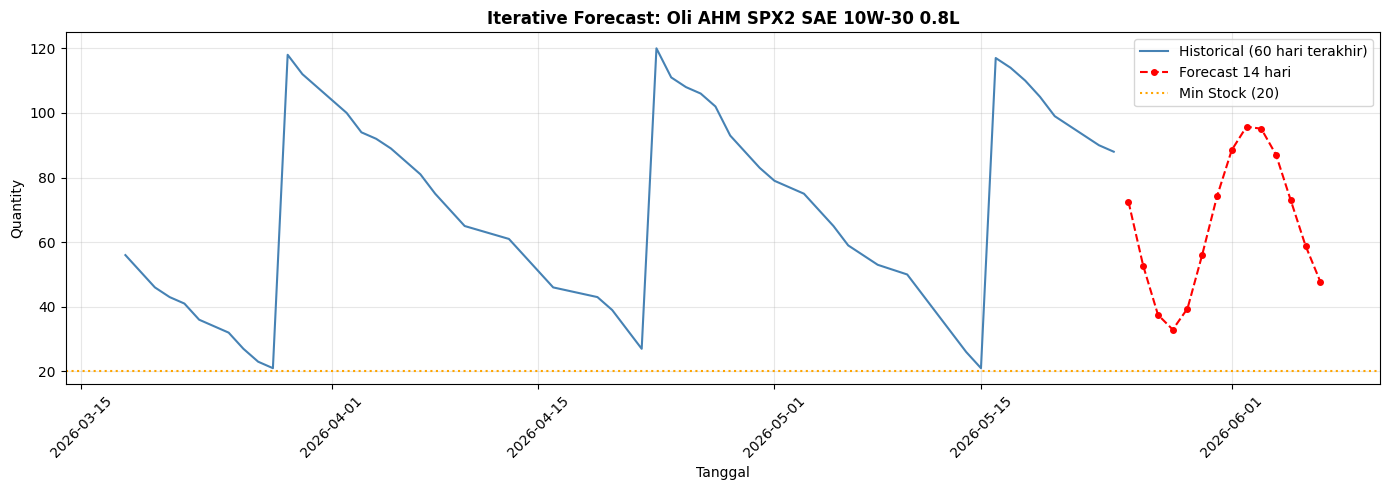


Forecast 14 hari:
         date  predicted
0  2026-05-25  72.503968
1  2026-05-26  52.650407
2  2026-05-27  37.501944
3  2026-05-28  32.937572
4  2026-05-29  39.458535
5  2026-05-30  56.148189
6  2026-05-31  74.156415
7  2026-06-01  88.513839
8  2026-06-02  95.746034
9  2026-06-03  95.116775
10 2026-06-04  87.061747
11 2026-06-05  72.960124
12 2026-06-06  58.932766
13 2026-06-07  47.824567


In [9]:
def iterative_forecast(df_feat, model, scaler, horizon=14):
    """Iterative forecast: predict day-by-day, update lag features."""
    history = list(df_feat['quantity'].values)
    last_date = df_feat['date'].iloc[-1]
    forecasts = []

    for day in range(1, horizon + 1):
        next_date = last_date + pd.Timedelta(days=day)
        dow = next_date.dayofweek
        is_we = 1 if dow >= 5 else 0
        day_num = len(df_feat) + day - 1

        lag1 = history[-1]
        lag3 = history[-3] if len(history) >= 3 else history[-1]
        lag7 = history[-7] if len(history) >= 7 else history[-1]
        roll_mean = np.mean(history[-7:])
        roll_std = np.std(history[-7:])
        daily_change = history[-1] - history[-2] if len(history) >= 2 else 0

        feat = np.array([[lag1, lag3, lag7, roll_mean, roll_std, dow, is_we, day_num, daily_change]])
        feat_scaled = scaler.transform(feat)
        pred = model.predict(feat_scaled)[0]
        pred = max(0, pred)  # clamp non-negative

        forecasts.append({'date': next_date, 'predicted': pred})
        history.append(pred)

    return pd.DataFrame(forecasts)

fc = iterative_forecast(df_feat, m3, scaler, horizon=14)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_feat['date'].iloc[-60:], df_feat['quantity'].iloc[-60:], label='Historical (60 hari terakhir)', color='steelblue', linewidth=1.5)
ax.plot(fc['date'], fc['predicted'], label='Forecast 14 hari', color='red', linestyle='--', marker='o', markersize=4)
ax.axhline(inventory[sample_id]['minStock'], color='orange', linestyle=':', label=f"Min Stock ({inventory[sample_id]['minStock']})")
ax.set_title(f'Iterative Forecast: {sample_name}', fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Quantity')
ax.legend()
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('\nForecast 14 hari:')
print(fc)

## 10. Ringkasan Semua Item (Multi Linear + Scaled)

In [10]:
summaries = []

for item_id, df in series_per_item.items():
    if len(df) < 60:
        continue
    df_f = build_features(df)
    df_f['target'] = df_f['quantity'].shift(-1)
    df_f = df_f.dropna().reset_index(drop=True)
    if len(df_f) < 30:
        continue

    split = int(len(df_f) * 0.8)
    train_d, test_d = df_f.iloc[:split], df_f.iloc[split:]

    sc = StandardScaler()
    Xtr = sc.fit_transform(train_d[feat_cols])
    Xte = sc.transform(test_d[feat_cols])

    mod = LinearRegression().fit(Xtr, train_d['target'])
    pred = mod.predict(Xte)

    summaries.append({
        'Item': inventory[item_id]['name'][:35],
        'N Days': len(df),
        'MAE': mean_absolute_error(test_d['target'], pred),
        'RMSE': np.sqrt(mean_squared_error(test_d['target'], pred)),
        'R²': r2_score(test_d['target'], pred),
    })

summary_df = pd.DataFrame(summaries).sort_values('R²', ascending=False)
print(f'\nTotal items: {len(summary_df)}')
print(f'Avg R²:  {summary_df["R²"].mean():.4f}')
print(f'Median R²: {summary_df["R²"].median():.4f}')
print(f'R² > 0.5: {(summary_df["R²"] > 0.5).sum()}/{len(summary_df)}')
print(f'R² > 0.7: {(summary_df["R²"] > 0.7).sum()}/{len(summary_df)}')
summary_df


Total items: 20
Avg R²:  0.6139
Median R²: 0.6305
R² > 0.5: 18/20
R² > 0.7: 2/20


,Item,N Days,MAE,RMSE,R²
17,Bohlam Depan H6M 12V 35W,241,4.163911,7.095944,0.738515
2,Oli Gear AHM Matic 0.12L,345,6.393229,12.730297,0.701361
8,Minyak Rem AHM DOT 4 0.1L,306,4.468718,9.993103,0.674057
3,Filter Oli 15412-KVB-901 (Beat/Vari,324,5.513472,9.532624,0.669362
9,Busi NGK CPR8EA-9 (Beat/Vario),322,5.102498,12.920001,0.664169
10,Busi NGK CPR9EA-9 (Sport),235,4.879421,9.762533,0.643965
6,Kampas Rem Depan 06455-K44-V01 (Var,286,3.757023,6.974337,0.640668
1,Oli AHM MPX2 SAE 10W-30 0.8L,333,9.789652,17.137171,0.633808
18,Kampas Kopling 22535-KVG-900 (Sport,155,1.897891,3.105276,0.633263
5,Filter Udara 17210-K46-N10 (Vario 1,303,3.770333,8.304491,0.633043


## Kesimpulan

Model **Multi Linear Regression dengan StandardScaler** kemungkinan terbaik untuk dataset ini karena:
- Lag features menangkap dependensi temporal
- StandardScaler menormalkan skala antar features
- Day-of-week menangkap pola mingguan

**Catatan:** R² rendah pada data dengan restock irregular adalah normal karena event restock memang sulit diprediksi dari pola konsumsi semata.